<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/SERIES_TEMPORAIS_Previs%C3%A3o_de_Vendas_diarias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabalho: Previsão de Vendas diária**

O objetivo principal é transformar dados transacionais em uma série temporal e realizar a previsão de vendas diárias para um departamento específico.

**1. Preparação dos Dados (Data Prep):**

Agregação: Converter as transações em uma série diária, utilizando a soma do valor das vendas como método de acumulação.

*   Saneamento
*   Datas Faltantes: Identificar lacunas no calendário e preenchê-las (imputação ou zero) para garantir que a série seja igualmente espaçada.
*  Vendas Negativas: Tratar valores negativos (erros de registro) por meio de imputação, como a média do período.

Foco da Análise: Priorizar os Departamentos 2 ou 4, que juntos representam cerca de 95% do faturamento total.

**2. Estratégia de Modelagem:**

Divisão da Base: Utilizar os anos de 2018, 2019 e 2020 para treino e o ano de 2021 para teste (Holdout).

Análise Inicial:

* Visualização: Plotar recortes da série para identificar tendência e sazonalidade.

* Testes Estatísticos: Validar se a série é Ruído Branco (se for, não há padrão para prever) e verificar a Estacionariedade.

**3. Execução e Avaliação:**

Escolha do Modelo: Identificar se há tendência e sazonalidade para selecionar a técnica adequada (Alisamento Exponencial Simples, Holt ou Holt-Winters).

Validação:
* Comparar os valores previstos com os reais da base de teste (2021).

* Calcular métricas de erro (como o MAPE) e garantir que os resíduos do modelo se comportem como ruído branco, provando que o sinal foi capturado corretamente.
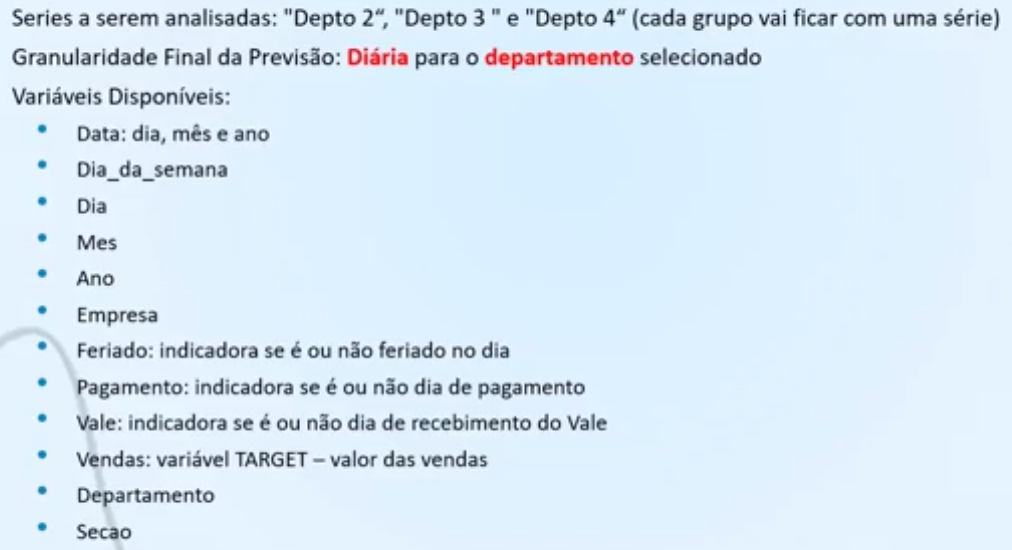

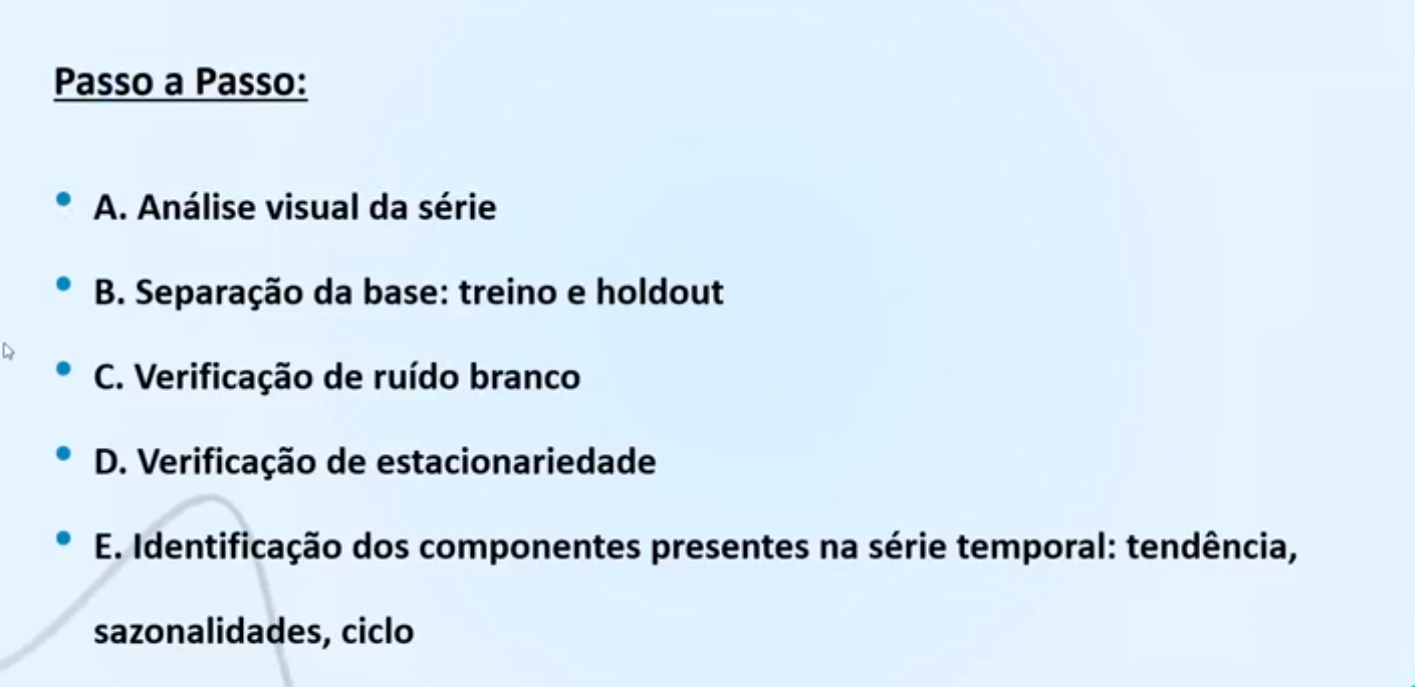

BIBLIOTECAS

In [83]:
from dateutil.parser import parse
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.api as sm
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

import dateutil
import calendar

import matplotlib.pyplot as plt
print('✅ Bibliotecas carregadas!')

✅ Bibliotecas carregadas!


1. CARREGAR DADOS

In [2]:
!pip install gdown # ponte entre Google Drive e Python

In [3]:
import gdown

file_id = "1wJBE7re7rSQ-ZhIyrAXjEA6rt5WGxBQW"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "Vendas_ASN_Dados_Finais.csv",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1wJBE7re7rSQ-ZhIyrAXjEA6rt5WGxBQW
To: /content/Vendas_ASN_Dados_Finais.csv
100%|██████████| 21.4M/21.4M [00:00<00:00, 111MB/s] 


'Vendas_ASN_Dados_Finais.csv'

In [35]:
data = pd.read_csv('Vendas_ASN_Dados_Finais.csv')
data.head(10)

,Data,Data_new,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção
0,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,316.58,Depto 1,Seção 1
1,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"94,195.95",Depto 2,Seção 2
2,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"60,170.14",Depto 2,Seção 3
3,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"48,120.35",Depto 2,Seção 4
4,01/02/18,1/2/2018,3,2,1,2018,2,0,0,0,"2,622.62",Depto 3,Seção 7
5,01/02/18,1/2/2018,3,2,1,2018,5,0,0,0,"21,277.82",Depto 2,Seção 26
6,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,155.12,Depto 3,Seção 5
7,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"9,963.10",Depto 3,Seção 6
8,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"18,400.85",Depto 3,Seção 7
9,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"5,114.59",Depto 3,Seção 8


In [36]:
# ver formato que está a data

data = data.drop(columns=['Data_new'])
data.head(10)

,Data,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção
0,01/02/18,3,2,1,2018,1,0,0,0,316.58,Depto 1,Seção 1
1,01/02/18,3,2,1,2018,1,0,0,0,"94,195.95",Depto 2,Seção 2
2,01/02/18,3,2,1,2018,1,0,0,0,"60,170.14",Depto 2,Seção 3
3,01/02/18,3,2,1,2018,1,0,0,0,"48,120.35",Depto 2,Seção 4
4,01/02/18,3,2,1,2018,2,0,0,0,"2,622.62",Depto 3,Seção 7
5,01/02/18,3,2,1,2018,5,0,0,0,"21,277.82",Depto 2,Seção 26
6,01/02/18,3,2,1,2018,1,0,0,0,155.12,Depto 3,Seção 5
7,01/02/18,3,2,1,2018,1,0,0,0,"9,963.10",Depto 3,Seção 6
8,01/02/18,3,2,1,2018,1,0,0,0,"18,400.85",Depto 3,Seção 7
9,01/02/18,3,2,1,2018,1,0,0,0,"5,114.59",Depto 3,Seção 8


In [37]:
data['Data'] = pd.to_datetime(data['Data'])

/tmp/ipykernel_2701/3475004564.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Data'] = pd.to_datetime(data['Data'])


In [38]:
data['Data'].head()
data['Data'].dtype

dtype('<M8[ns]')

In [40]:
data['Data_BR'] = data['Data'].dt.strftime('%d/%m/%Y')

data['Data_BR'] = pd.to_datetime(
    data['Data_BR'],
    format='%d/%m/%Y'
)

In [41]:
data['Data_BR'].dtype

dtype('<M8[ns]')

In [28]:
# Data no formato brasileiro e como data:

data.head(10)

,Data,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção,Data_BR
0,2018-01-02,3,2,1,2018,1,0,0,0,316.58,Depto 1,Seção 1,02/01/2018
1,2018-01-02,3,2,1,2018,1,0,0,0,"94,195.95",Depto 2,Seção 2,02/01/2018
2,2018-01-02,3,2,1,2018,1,0,0,0,"60,170.14",Depto 2,Seção 3,02/01/2018
3,2018-01-02,3,2,1,2018,1,0,0,0,"48,120.35",Depto 2,Seção 4,02/01/2018
4,2018-01-02,3,2,1,2018,2,0,0,0,"2,622.62",Depto 3,Seção 7,02/01/2018
5,2018-01-02,3,2,1,2018,5,0,0,0,"21,277.82",Depto 2,Seção 26,02/01/2018
6,2018-01-02,3,2,1,2018,1,0,0,0,155.12,Depto 3,Seção 5,02/01/2018
7,2018-01-02,3,2,1,2018,1,0,0,0,"9,963.10",Depto 3,Seção 6,02/01/2018
8,2018-01-02,3,2,1,2018,1,0,0,0,"18,400.85",Depto 3,Seção 7,02/01/2018
9,2018-01-02,3,2,1,2018,1,0,0,0,"5,114.59",Depto 3,Seção 8,02/01/2018


2. TRANSFORMAR DADOS TRANSACIONAIS EM AGREGADOS

Método de acumulação - soma

Intervalo de tempo - diária

In [42]:
data['Vendas'] = (
    data['Vendas']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# QUANTAS VENDAS TEM POR DEPARTAMENTO?

total_departamento = (
    data.groupby('Departamento', as_index=False)['Vendas']
      .sum()
)

# Total geral
total_geral = total_departamento['Vendas'].sum()

# Percentual de participação
total_departamento['Perc'] = (
    total_departamento['Vendas'] / total_geral * 100
)

# Valor em milhões
total_departamento['Vendas_MM'] = (
    total_departamento['Vendas'] / 1_000_000
)

# Formatação
total_departamento['Vendas_MM'] = (
    total_departamento['Vendas_MM']
    .map(lambda x: f'{x:,.2f} MM')
)

total_departamento['Perc'] = (
    total_departamento['Perc']
    .map(lambda x: f'{x:.2f}%')
)

print(total_departamento)

  Departamento        Vendas    Perc    Vendas_MM
0      Depto 1  5.295840e+06   0.09%      5.30 MM
1      Depto 2  3.265787e+09  54.12%  3,265.79 MM
2     Depto 3   2.474437e+08   4.10%    247.44 MM
3      Depto 4  2.460234e+09  40.77%  2,460.23 MM
4      Depto 5  5.052954e+07   0.84%     50.53 MM
5      Depto 6  4.219464e+06   0.07%      4.22 MM
6      Depto 7  9.759944e+05   0.02%      0.98 MM


Para continuar a análise, foi escolhido o departamento 4 por representar 41% das vendas.

In [44]:
data_depto4 = data[data['Departamento'] == 'Depto 4'].copy()

vendas_dia = (
    data_depto4.groupby(['Data_BR'])['Vendas']
      .sum()
      .reset_index()
)

print(vendas_dia)


        Data_BR      Vendas
0    2018-01-02  1812134.19
1    2018-01-03  1622115.60
2    2018-01-04  1486888.42
3    2018-01-05  2015469.36
4    2018-01-06  2678387.64
...         ...         ...
1143 2021-02-24  2025751.85
1144 2021-02-25  2216224.47
1145 2021-02-26  3098829.40
1146 2021-02-27  4592539.97
1147 2021-02-28  2157356.38

[1148 rows x 2 columns]


In [59]:
# ANÁLISE DA VARIÁVEL VENDA:

vendas_dia['Vendas'].describe()

,Vendas
count,1.148000e+03
mean,2.143061e+06
std,7.398696e+05
min,5.802061e+05
25%,1.632986e+06
50%,1.954044e+06
75%,2.459384e+06
max,5.363986e+06


In [67]:
vendas_dia['Ano'] = vendas_dia['Data_BR'].dt.year

vendas_dia.head(10)

,Data_BR,Vendas,Ano
0,2018-01-02,1812134.19,2018
1,2018-01-03,1622115.60,2018
2,2018-01-04,1486888.42,2018
3,2018-01-05,2015469.36,2018
4,2018-01-06,2678387.64,2018
5,2018-01-07,1120660.99,2018
6,2018-01-08,1600882.79,2018
7,2018-01-09,1963629.68,2018
8,2018-01-10,1667902.81,2018
9,2018-01-11,1457775.73,2018


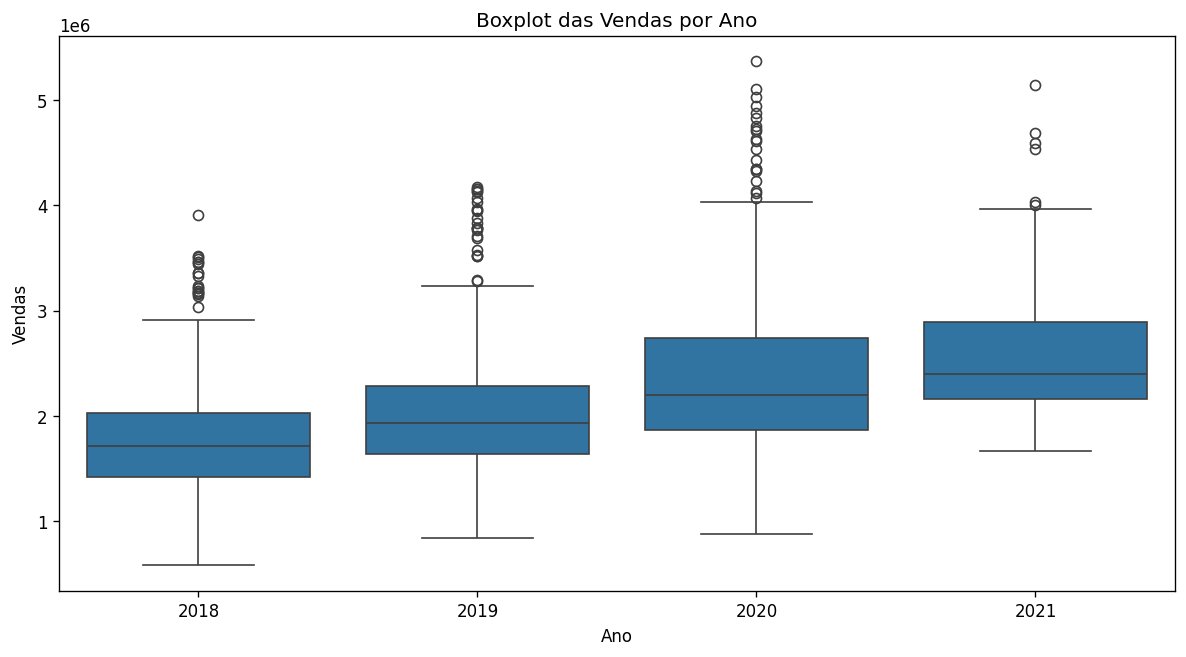

In [68]:
# BOXPLOT AO LONGO DOS ANOS:

fig, ax = plt.subplots(figsize=(12,6))

sns.boxplot(
    data=vendas_dia,
    x='Ano',
    y='Vendas',
    ax=ax
)

plt.title('Boxplot das Vendas por Ano')
plt.show()

In [69]:
vendas_dia.groupby('Ano')['Vendas'].describe()

,count,mean,std,min,25%,50%,75%,max
Ano,,,,,,,,
2018,363.0,1.827837e+06,579069.807873,580206.06,1.415357e+06,1710038.510,2.025495e+06,3906138.25
2019,363.0,2.089768e+06,640858.788881,836348.22,1.637741e+06,1932448.020,2.283950e+06,4168269.68
2020,364.0,2.427573e+06,814747.069522,878158.71,1.863710e+06,2201581.005,2.734793e+06,5363986.16
2021,58.0,2.663906e+06,778574.868966,1667474.63,2.161169e+06,2399303.330,2.891777e+06,5141515.66


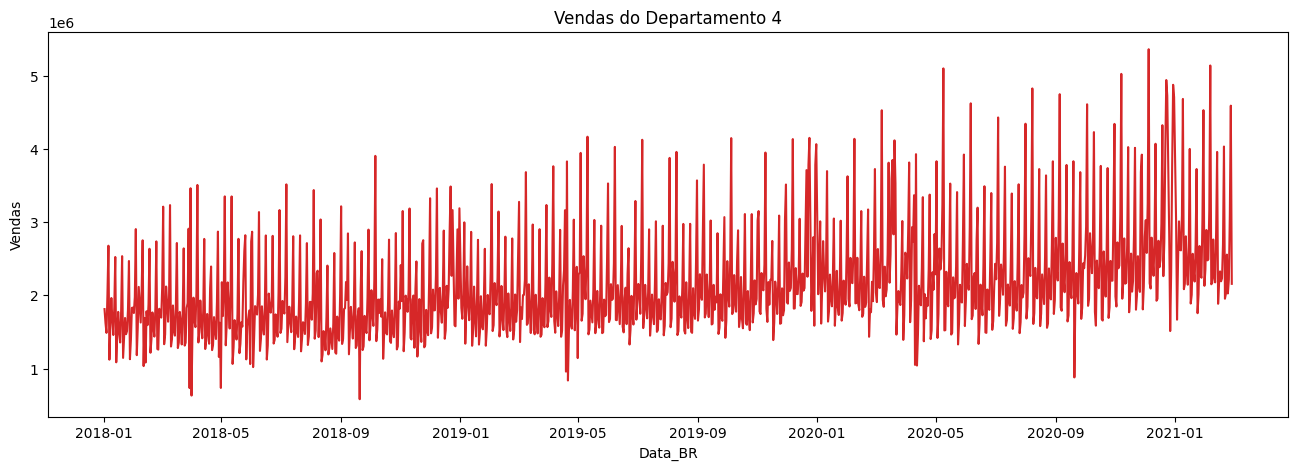

In [71]:
# Visualizando a série temporal

def plot_df(vendas_dia, x, y, title="", xlabel='Data_BR', ylabel='Vendas', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(
    vendas_dia=vendas_dia,
    x=vendas_dia['Data_BR'],
    y=vendas_dia['Vendas'],
    title='Vendas do Departamento 4'
)

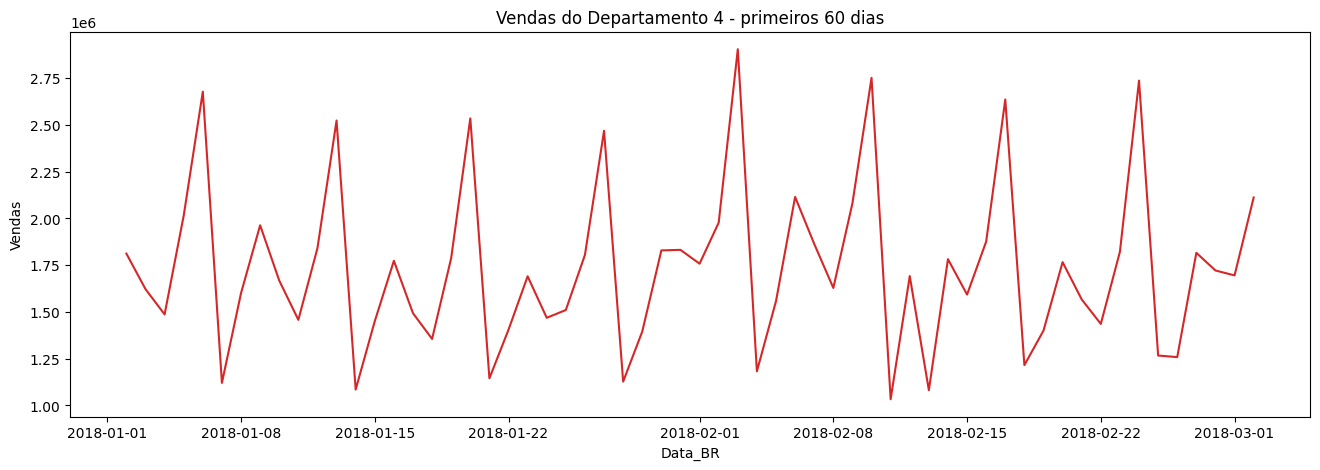

In [72]:
# Visualizando a série temporal em um intervalo de tempo menor

vendas_dia = vendas_dia.sort_values('Data_BR')

trecho = vendas_dia.iloc[:60]

plot_df(
    vendas_dia=trecho,
    x=trecho['Data_BR'],
    y=trecho['Vendas'],
    title='Vendas do Departamento 4 - primeiros 60 dias'
)

A série temporal apresenta comportamento predominantemente estacionário, sem tendência definida no período analisado. Observam-se oscilações diárias em torno de um nível médio aproximadamente constante, acompanhadas de elevada variabilidade e indícios de sazonalidade de curta duração, possivelmente semanal.

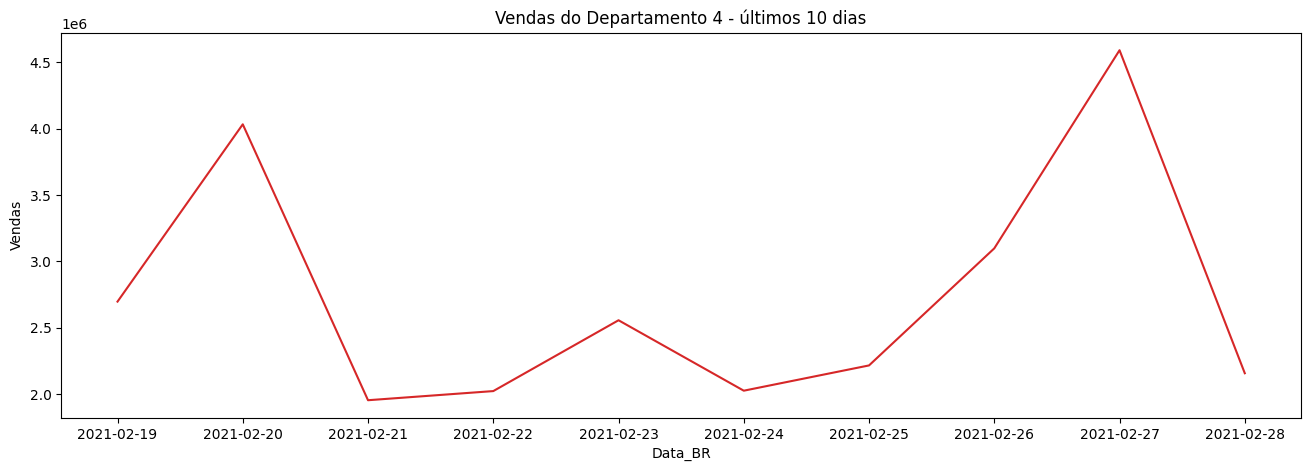

In [73]:
trecho = vendas_dia.iloc[-10:]

plot_df(
    vendas_dia=trecho,
    x=trecho['Data_BR'],
    y=trecho['Vendas'],
    title='Vendas do Departamento 4 - últimos 10 dias'
)

In [54]:
# Tem dias faltantes?
datas_completas = pd.date_range(
    start=vendas_dia['Data_BR'].min(),
    end=vendas_dia['Data_BR'].max(),
    freq='D'
)

faltantes = datas_completas.difference(vendas_dia['Data_BR'])

print(faltantes)
print('Quantidade de dias faltantes:', len(faltantes))

DatetimeIndex(['2018-12-25', '2019-01-01', '2019-12-25', '2020-01-01',
               '2020-12-25', '2021-01-01'],
              dtype='datetime64[ns]', freq=None)
Quantidade de dias faltantes: 6


In [74]:
# Imputar dias faltantes pela média do dia da semana no mes/ano

# Garantir formato datetime
vendas_dia['Data_BR'] = pd.to_datetime(vendas_dia['Data_BR'])

# Criar calendário completo
datas = pd.date_range(
    vendas_dia['Data_BR'].min(),
    vendas_dia['Data_BR'].max(),
    freq='D'
)

# Inserir datas faltantes
serie = (
    vendas_dia
    .set_index('Data_BR')
    .reindex(datas)
    .rename_axis('Data_BR')
    .reset_index()
)

# Variáveis auxiliares
serie['Ano'] = serie['Data_BR'].dt.year
serie['Mes'] = serie['Data_BR'].dt.month
serie['DiaSemana'] = serie['Data_BR'].dt.dayofweek

# Marcar observações originalmente faltantes
serie['Imputado'] = serie['Vendas'].isna()

# Média do mesmo dia da semana dentro do mesmo mês/ano
serie['Media_DS'] = (
    serie
    .groupby(['Ano','Mes','DiaSemana'])['Vendas']
    .transform('mean')
)

# Imputação
serie['Vendas'] = serie['Vendas'].fillna(serie['Media_DS'])

# Remover coluna auxiliar
serie.drop(columns='Media_DS', inplace=True)

In [75]:
serie.loc[serie['Imputado'], ['Data_BR','Vendas']]

,Data_BR,Vendas
357,2018-12-25,2.103518e+06
364,2019-01-01,2.127077e+06
722,2019-12-25,2.048224e+06
729,2020-01-01,2.024906e+06
1088,2020-12-25,3.006982e+06
1095,2021-01-01,2.875630e+06


In [76]:
serie['Vendas'].isna().sum()

np.int64(0)

## **DECOMPOSIÇÃO DA SÉRIE:**

ADITIVA E MULTIPLICATIVA

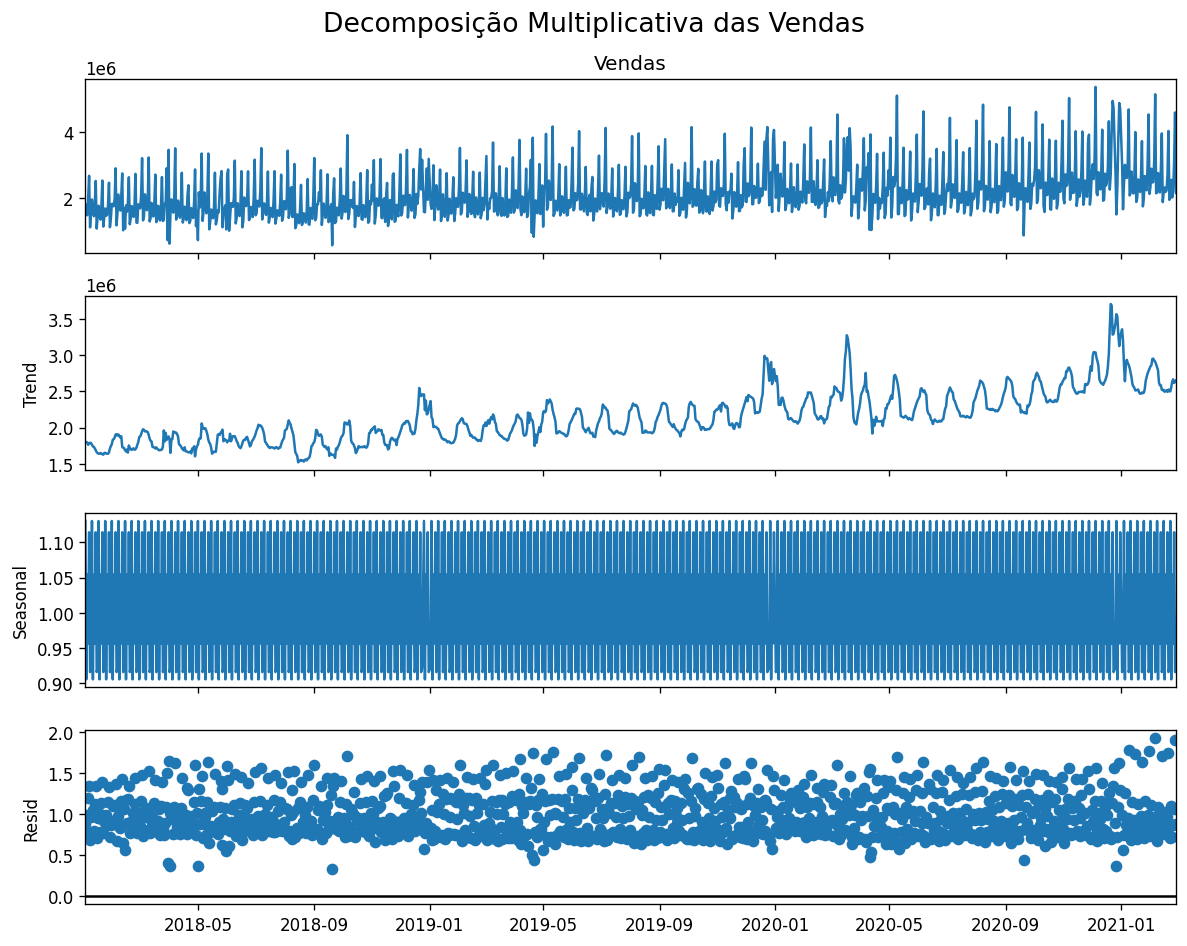

In [78]:
# PADRÃO SEMANAL
from statsmodels.tsa.seasonal import seasonal_decompose

serie = vendas_dia.copy()

serie = serie.set_index('Data_BR')

result_mul = seasonal_decompose(
    serie['Vendas'],
    model='multiplicative',
    period=7, # semanal
    extrapolate_trend='freq'
)

plt.rcParams.update({'figure.figsize': (10,8)})

result_mul.plot()

plt.suptitle(
    'Decomposição Multiplicativa das Vendas',
    fontsize=16
)

plt.tight_layout()
plt.show()

**Interpretação da decomposição:**

1. Série original (Vendas)

O primeiro gráfico mostra:

*   tendência crescente ao longo do tempo;
*   oscilações frequentes;
*  aumento da amplitude das vendas nos anos mais recentes;
*  alguns picos bastante elevados, principalmente em 2020 e 2021.

2. Tendência (Trend)

O componente de tendência mostra claramente:

*  crescimento gradual das vendas entre 2018 e 2021;
*  algumas oscilações acentuadas em 2020;
*  um pico importante próximo ao início de 2021.

Isso sugere que o departamento apresentou crescimento nas vendas ao longo do período analisado.

3. Sazonalidade (Seasonal)

A sazonalidade está muito regular (padrão semanal).
determinados dias da semana vendem cerca de 12% acima da média, enquanto outros ficam aproximadamente 10% abaixo.

4. Resíduos (Resid)

Os resíduos parecem:

*  relativamente centrados em torno de 1;
*  sem tendência aparente;
*  com alguns pontos extremos.

Isso é um bom sinal para um modelo multiplicativo.


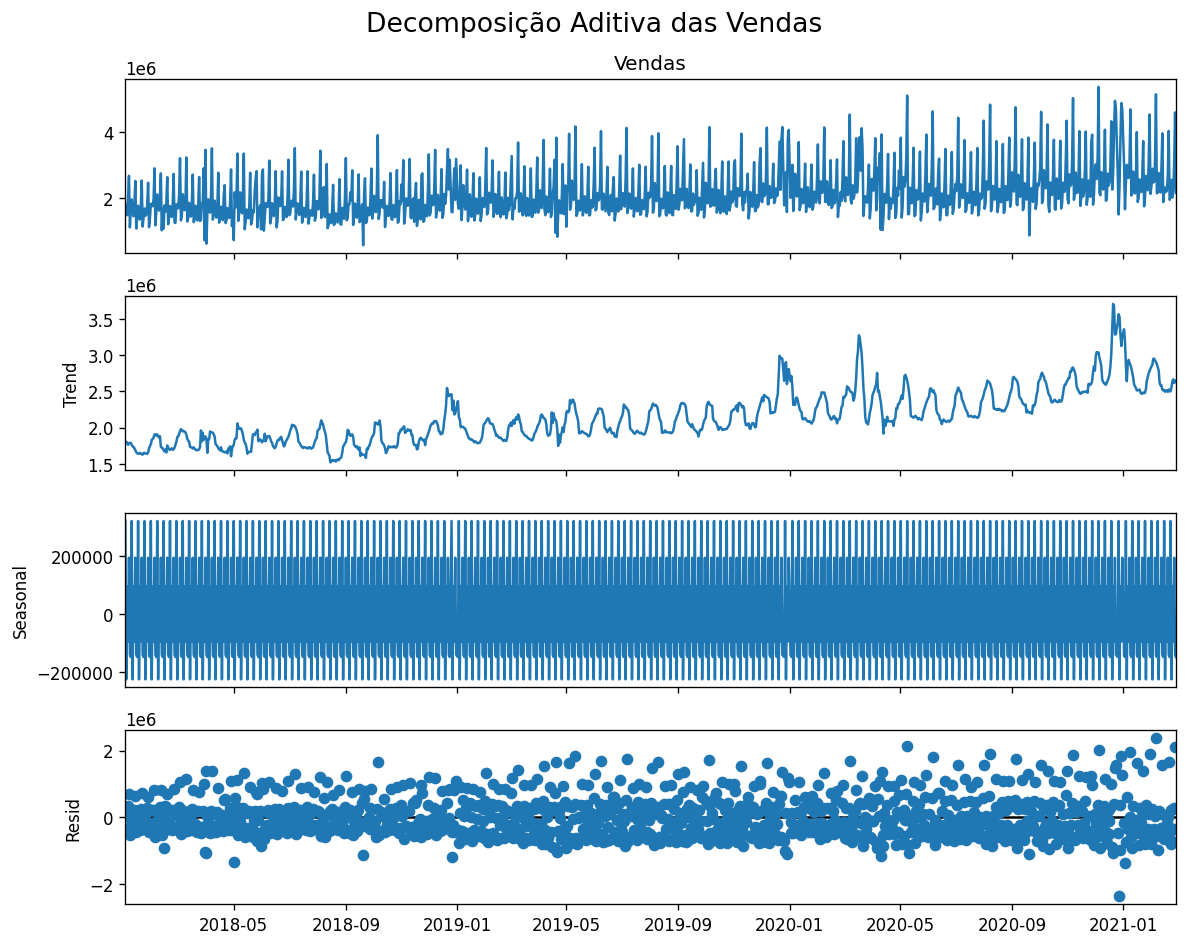

In [81]:
# PADRÃO SEMANAL
from statsmodels.tsa.seasonal import seasonal_decompose

serie = vendas_dia.copy()

serie = serie.set_index('Data_BR')

result_mul = seasonal_decompose(
    serie['Vendas'],
    model='additive',
    period=7, # semanal
    extrapolate_trend='freq'
)

plt.rcParams.update({'figure.figsize': (10,8)})

result_mul.plot()

plt.suptitle(
    'Decomposição Aditiva das Vendas',
    fontsize=16
)

plt.tight_layout()
plt.show()

A decomposição aditiva revelou uma tendência crescente das vendas ao longo do período analisado, acompanhada de um padrão sazonal semanal relativamente estável. O componente sazonal oscila em torno de zero, enquanto os resíduos permanecem centrados próximos de zero, indicando que a decomposição consegue capturar adequadamente parte da estrutura temporal da série. Entretanto, observa-se aumento da amplitude das flutuações ao longo do tempo, sugerindo que a decomposição multiplicativa pode representar melhor o comportamento dos dados.

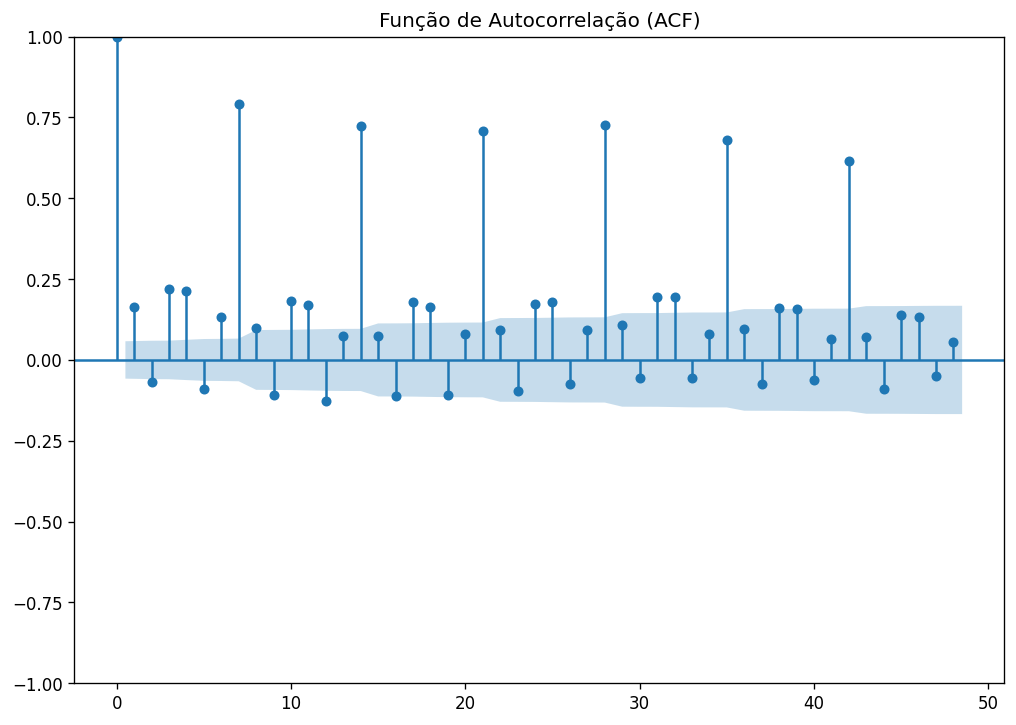

In [86]:
#4. Verificando autocorrelação
# Usando função ACF

fig = sm.graphics.tsa.plot_acf(
    vendas_dia['Vendas'],
    lags=48
)

plt.title('Função de Autocorrelação (ACF)')
plt.show()

A função de autocorrelação (ACF) evidencia a existência de dependência temporal entre as observações da série de vendas. Observam-se coeficientes de autocorrelação estatisticamente significativos em diversos defasagens, com destaque para os lags múltiplos de sete dias (7, 14, 21, 28, 35 e 42), indicando a presença de sazonalidade semanal. Além disso, a persistência das autocorrelações ao longo das defasagens sugere que a série apresenta comportamento não aleatório, com componentes de tendência e sazonalidade já identificadas na etapa de decomposição.

## **RUÍDO BRANCO:**

In [89]:
# Verificando se a série é um Ruído Branco

from statsmodels.stats.diagnostic import acorr_ljungbox

# H0: a série é um ruído branco
# H1: a série não é um ruído branco

lb = acorr_ljungbox(
    vendas_dia['Vendas'],
    lags=[5],
    return_df=True
)

print(lb)

pvalor = lb['lb_pvalue'].iloc[0]

print('\n========================')
print('Teste de Ljung-Box')
print('========================')

print(f'Estatística: {lb["lb_stat"].iloc[0]:.4f}')
print(f'p-valor: {pvalor:.4e}')

if pvalor < 0.05:
    print('\nConclusão: rejeita-se H0.')
    print('A série NÃO é um ruído branco.')
else:
    print('\nConclusão: não se rejeita H0.')
    print('A série pode ser considerada um ruído branco.')

      lb_stat     lb_pvalue
5  153.810764  2.061383e-31

Teste de Ljung-Box
Estatística: 153.8108
p-valor: 2.0614e-31

Conclusão: rejeita-se H0.
A série NÃO é um ruído branco.


## **ESTACIONARIDADE:**

In [88]:
# Verificando se a série é estacionária

from statsmodels.tsa.stattools import adfuller, kpss

# Série temporal
serie = vendas_dia.set_index('Data_BR')

y = serie['Vendas']

# Teste ADF

print('========================')
print('Teste ADF')
print('========================')

adf = adfuller(y, autolag='AIC')

print(f'ADF Statistic: {adf[0]}')
print(f'p-value: {adf[1]}')

print('\nValores críticos:')
for key, value in adf[4].items():
    print(f'{key}: {value}')

if adf[1] < 0.05:
    print('\nConclusão: rejeita-se H0.')
    print('A série é estacionária.')
else:
    print('\nConclusão: não se rejeita H0.')
    print('A série não é estacionária.')

Teste ADF
ADF Statistic: -2.548324705742626
p-value: 0.10415460938346788

Valores críticos:
1%: -3.4361656672131806
5%: -2.864107957764881
10%: -2.568137251515397

Conclusão: não se rejeita H0.
A série não é estacionária.
